# Notebook 04 — Topic Clustering for Subject Areas

**Goal:** Discover latent topics in the corpus and generate sub-topic clusters for each WoS subject area. This satisfies the second requirement of the project.

> **Personal note:** This is my favourite part of the project. I used two complementary approaches: global LDA (which gives interpretable word-based topics across the whole corpus) and per-subject UMAP + HDBSCAN (which gives geometrically coherent clusters in embedding space). The combination gives both word-level and semantic-level insights into how CS research is structured.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

df = pd.read_parquet("../data/processed/processed_df.parquet")
print(f"Loaded: {len(df):,} articles, {df['journal_id'].nunique()} journals")

pathlib.Path("../data/outputs").mkdir(parents=True, exist_ok=True)


Loaded: 20,944 articles, 410 journals


## 1. LDA Coherence Sweep — Choosing Optimal K

> I swept K ∈ {20, 30, 40, 50, 70, 80}. The cached coherence table peaks at K=20, while K=50 gives a finer-grained map that is more useful for exploratory topic interpretation across a broad CS corpus. We therefore keep K=50 for the recommender/topic visualisation, but we should not describe it as the coherence-maximising choice.

**Note:** This sweep takes 20–40 minutes. Results are cached.


In [2]:
import pickle

coherence_cache = pathlib.Path("../data/processed/coherence_sweep.pkl")

if coherence_cache.exists():
    import pickle
    with open(coherence_cache, "rb") as f:
        coherence_df = pickle.load(f)
    print("Loaded cached coherence sweep.")
else:
    from src.clustering import sweep_lda_coherence

    tokenized = [t.split() for t in df["processed_text"].fillna("").tolist()]
    coherence_df = sweep_lda_coherence(
        tokenized, k_range=[20, 30, 40, 50, 70, 80], passes=5, workers=1
    )
    with open(coherence_cache, "wb") as f:
        pickle.dump(coherence_df, f)

print(coherence_df.to_string())


Loaded cached coherence sweep.
    K  coherence_cv
0  20      0.537616
1  30      0.533364
2  40      0.506049
3  50      0.495919
4  70      0.483267
5  80      0.474232


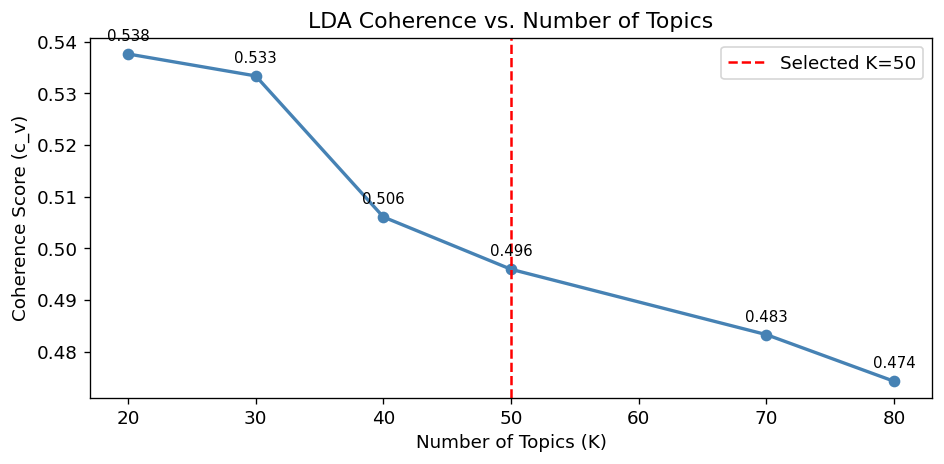

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(coherence_df["K"], coherence_df["coherence_cv"], marker="o", color="steelblue", linewidth=2)
for _, row in coherence_df.iterrows():
    ax.annotate(f"{row['coherence_cv']:.3f}", (row["K"], row["coherence_cv"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xlabel("Number of Topics (K)")
ax.set_ylabel("Coherence Score (c_v)")
ax.set_title("LDA Coherence vs. Number of Topics")
ax.axvline(50, color="red", linestyle="--", label="Selected K=50")
ax.legend()
plt.tight_layout()
plt.savefig("../data/outputs/fig_lda_coherence.png", bbox_inches="tight", dpi=150)
plt.show()


## 2. Global LDA — Topic Exploration

We load the LDA model trained in Notebook 02 (K=50, full corpus) and explore its topics.


In [4]:
from src.recommender import LDARecommender

lda_rec = LDARecommender.load()
lda_model   = lda_rec.lda_model
dictionary  = lda_rec.dictionary
corpus      = lda_rec.corpus

print(f"LDA model: {lda_model.num_topics} topics")
print(f"Dictionary: {len(dictionary):,} tokens")


[LDA] Loaded from C:\Users\zehra\Masaüstü\dm\journal-finder\models\lda_recommender.pkl
LDA model: 50 topics
Dictionary: 10,816 tokens


In [5]:
# Print all 50 topics
print("=" * 70)
print("LDA TOPICS (K=50) — Top 10 words per topic")
print("=" * 70)
for tid in range(lda_model.num_topics):
    words = [w for w, _ in lda_model.show_topic(tid, topn=10)]
    print(f"Topic {tid:3d}: {', '.join(words)}")


LDA TOPICS (K=50) — Top 10 words per topic
Topic   0: control, distance, similarity, measure, attribute, controller, base, xml, database, structure
Topic   1: flow, surface, element, simulation, structure, finite, numerical, mesh, water, fluid
Topic   2: network, node, protocol, hoc, rout, telecommunication, wireless, traffic, optical, packet
Topic   3: service, search, web, location, quality, qos, composition, base, orient, discovery
Topic   4: logic, language, program, semantic, verification, theory, transformation, formal, check, specification
Topic   5: semantic, knowledge, ontology, information, quantum, text, base, web, document, representation
Topic   6: social, medium, community, event, network, information, rdf, sentiment, share, tag
Topic   7: grid, filter, embed, resolution, hide, gamma, reversible, filtering, datum, expansion
Topic   8: function, type, linear, theory, family, vertical, bar, non, calculus, mathematic
Topic   9: recognition, speech, signal, emotion, face, fea

### pyLDAvis Interactive Visualisation

> pyLDAvis is one of my favourite data visualisation tools — the interactive bubble chart shows how topics relate to each other and what their top words are. Topics that are close together in the 2D map share vocabulary; topics far apart are more distinct.


In [6]:
from src.clustering import save_pyldavis

vis_path = save_pyldavis(lda_model, corpus, dictionary,
                          out_path=pathlib.Path("../data/outputs/lda_vis.html"))
print(f"Open {vis_path} in a browser to explore topics interactively.")

# Also display inline (works in some Jupyter environments)
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
vis_data = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.display(vis_data)


[pyLDAvis] Saved to ..\data\outputs\lda_vis.html
Open ..\data\outputs\lda_vis.html in a browser to explore topics interactively.


## 3. Per-Subject UMAP + HDBSCAN Clustering

For each WoS subject area, we:
1. Take the SBERT embeddings of all its articles
2. Reduce to 5-D with UMAP (for HDBSCAN)
3. Cluster with HDBSCAN
4. Label each cluster with its top TF-IDF terms
5. Visualise in 2-D UMAP space

> **Why HDBSCAN over k-means?** HDBSCAN is density-based — it doesn't require specifying the number of clusters in advance, handles clusters of varying shapes and sizes, and explicitly marks noise points (papers that don't fit into any cluster). This is much more realistic than forcing every paper into a cluster.


In [7]:
# Load SBERT embeddings (full corpus, from notebook 02)
emb_path = pathlib.Path("../data/processed/sbert_embeddings.npy")
if emb_path.exists():
    all_embeddings = np.load(str(emb_path))
    print(f"Loaded SBERT embeddings: {all_embeddings.shape}")
else:
    print("SBERT embeddings not found. Run notebook 02 first.")
    raise FileNotFoundError("Run notebook 02 first to generate SBERT embeddings.")


Loaded SBERT embeddings: (20944, 384)


In [8]:
from src.clustering import cluster_subject

# Run for each CS subject
cs_subjects = [
    "Computer Science, Artificial Intelligence",
    "Computer Science, Information Systems",
    "Computer Science, Software Engineering",
    "Computer Science, Theory & Methods",
    "Computer Science, Hardware & Architecture",
    "Computer Science, Cybernetics",
    "Computer Science, Interdisciplinary Applications",
]

clustered_subjects = {}
for subj in cs_subjects:
    # Find articles with this subject
    mask = df["subjects"].apply(lambda s: subj in s if isinstance(s, (list, np.ndarray)) else False)
    sub_df   = df[mask].copy().reset_index(drop=True)
    sub_embs = all_embeddings[mask.values]

    if len(sub_df) < 20:
        print(f"  Skipping '{subj}' — only {len(sub_df)} articles.")
        continue

    clustered = cluster_subject(sub_df, sub_embs, subject_name=subj,
                                min_cluster_size=15)
    clustered_subjects[subj] = clustered


  [UMAP+HDBSCAN] 'Computer Science, Artificial Intelligence': 4895 articles …
  [UMAP+HDBSCAN] 'Computer Science, Artificial Intelligence': 87 clusters, noise=28.6%
  [UMAP+HDBSCAN] 'Computer Science, Information Systems': 6879 articles …
  [UMAP+HDBSCAN] 'Computer Science, Information Systems': 108 clusters, noise=31.1%
  [UMAP+HDBSCAN] 'Computer Science, Software Engineering': 5733 articles …
  [UMAP+HDBSCAN] 'Computer Science, Software Engineering': 94 clusters, noise=34.0%
  [UMAP+HDBSCAN] 'Computer Science, Theory & Methods': 5543 articles …
  [UMAP+HDBSCAN] 'Computer Science, Theory & Methods': 89 clusters, noise=29.3%
  [UMAP+HDBSCAN] 'Computer Science, Hardware & Architecture': 2749 articles …
  [UMAP+HDBSCAN] 'Computer Science, Hardware & Architecture': 48 clusters, noise=25.4%
  [UMAP+HDBSCAN] 'Computer Science, Cybernetics': 604 articles …
  [UMAP+HDBSCAN] 'Computer Science, Cybernetics': 11 clusters, noise=15.4%
  [UMAP+HDBSCAN] 'Computer Science, Interdisciplinary Applicat

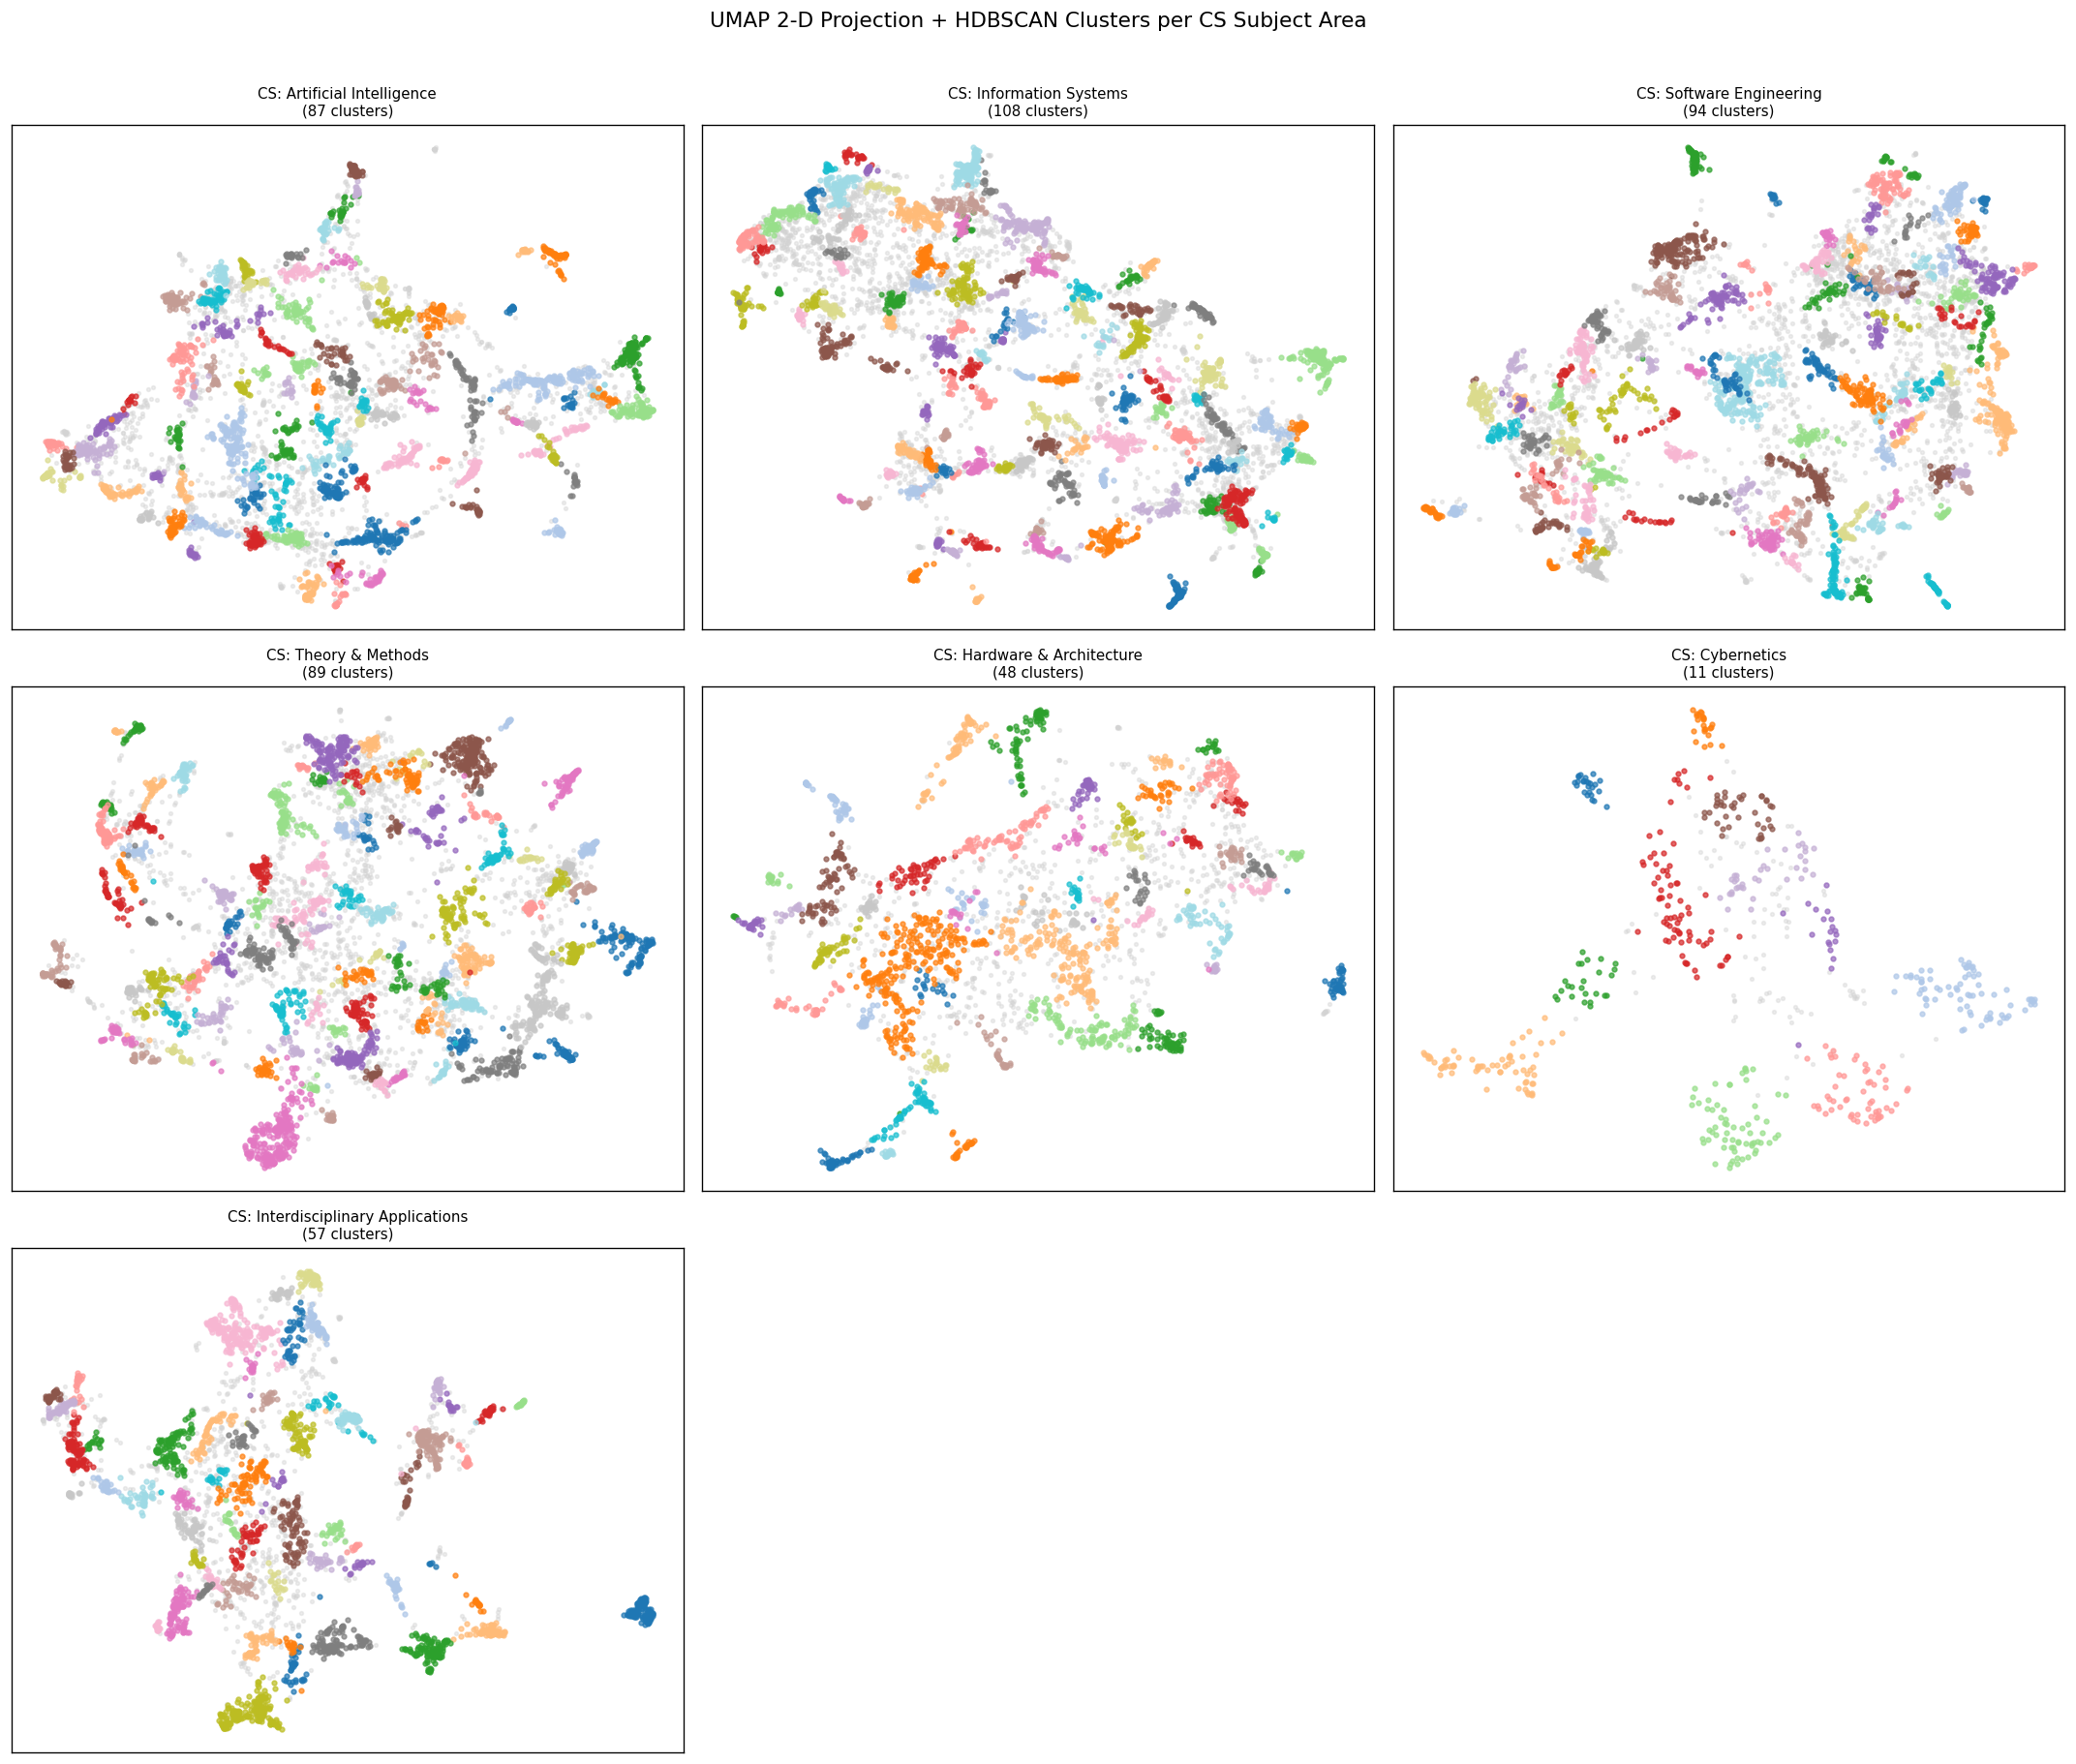

In [9]:
# Visualise clusters for each subject
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for ax_idx, (subj, df_c) in enumerate(clustered_subjects.items()):
    ax = axes[ax_idx]
    unique_clusters = sorted(df_c["cluster_id"].unique())
    noise_mask = df_c["cluster_id"] == -1

    # Plot noise in grey
    ax.scatter(df_c.loc[noise_mask, "umap_x"], df_c.loc[noise_mask, "umap_y"],
               c="lightgrey", s=5, alpha=0.4, label="noise")

    # Plot clusters with distinct colours
    palette = plt.cm.tab20.colors
    for cid in [c for c in unique_clusters if c != -1]:
        mask = df_c["cluster_id"] == cid
        ax.scatter(df_c.loc[mask, "umap_x"], df_c.loc[mask, "umap_y"],
                   c=[palette[cid % 20]], s=8, alpha=0.7,
                   label=df_c.loc[mask, "cluster_label"].iloc[0][:25])

    short = subj.replace("Computer Science, ", "CS: ")
    ax.set_title(f"{short}\n({df_c['cluster_id'].nunique()-1} clusters)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[len(clustered_subjects):]:
    ax.set_visible(False)

plt.suptitle("UMAP 2-D Projection + HDBSCAN Clusters per CS Subject Area",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/outputs/fig_umap_clusters.png", bbox_inches="tight", dpi=150)
plt.show()


## 4. Subject × Topic Heatmap

Visualises which LDA topics are most associated with each WoS subject area.


[Heatmap] Saved to ..\data\outputs\fig_subject_topic_heatmap.png


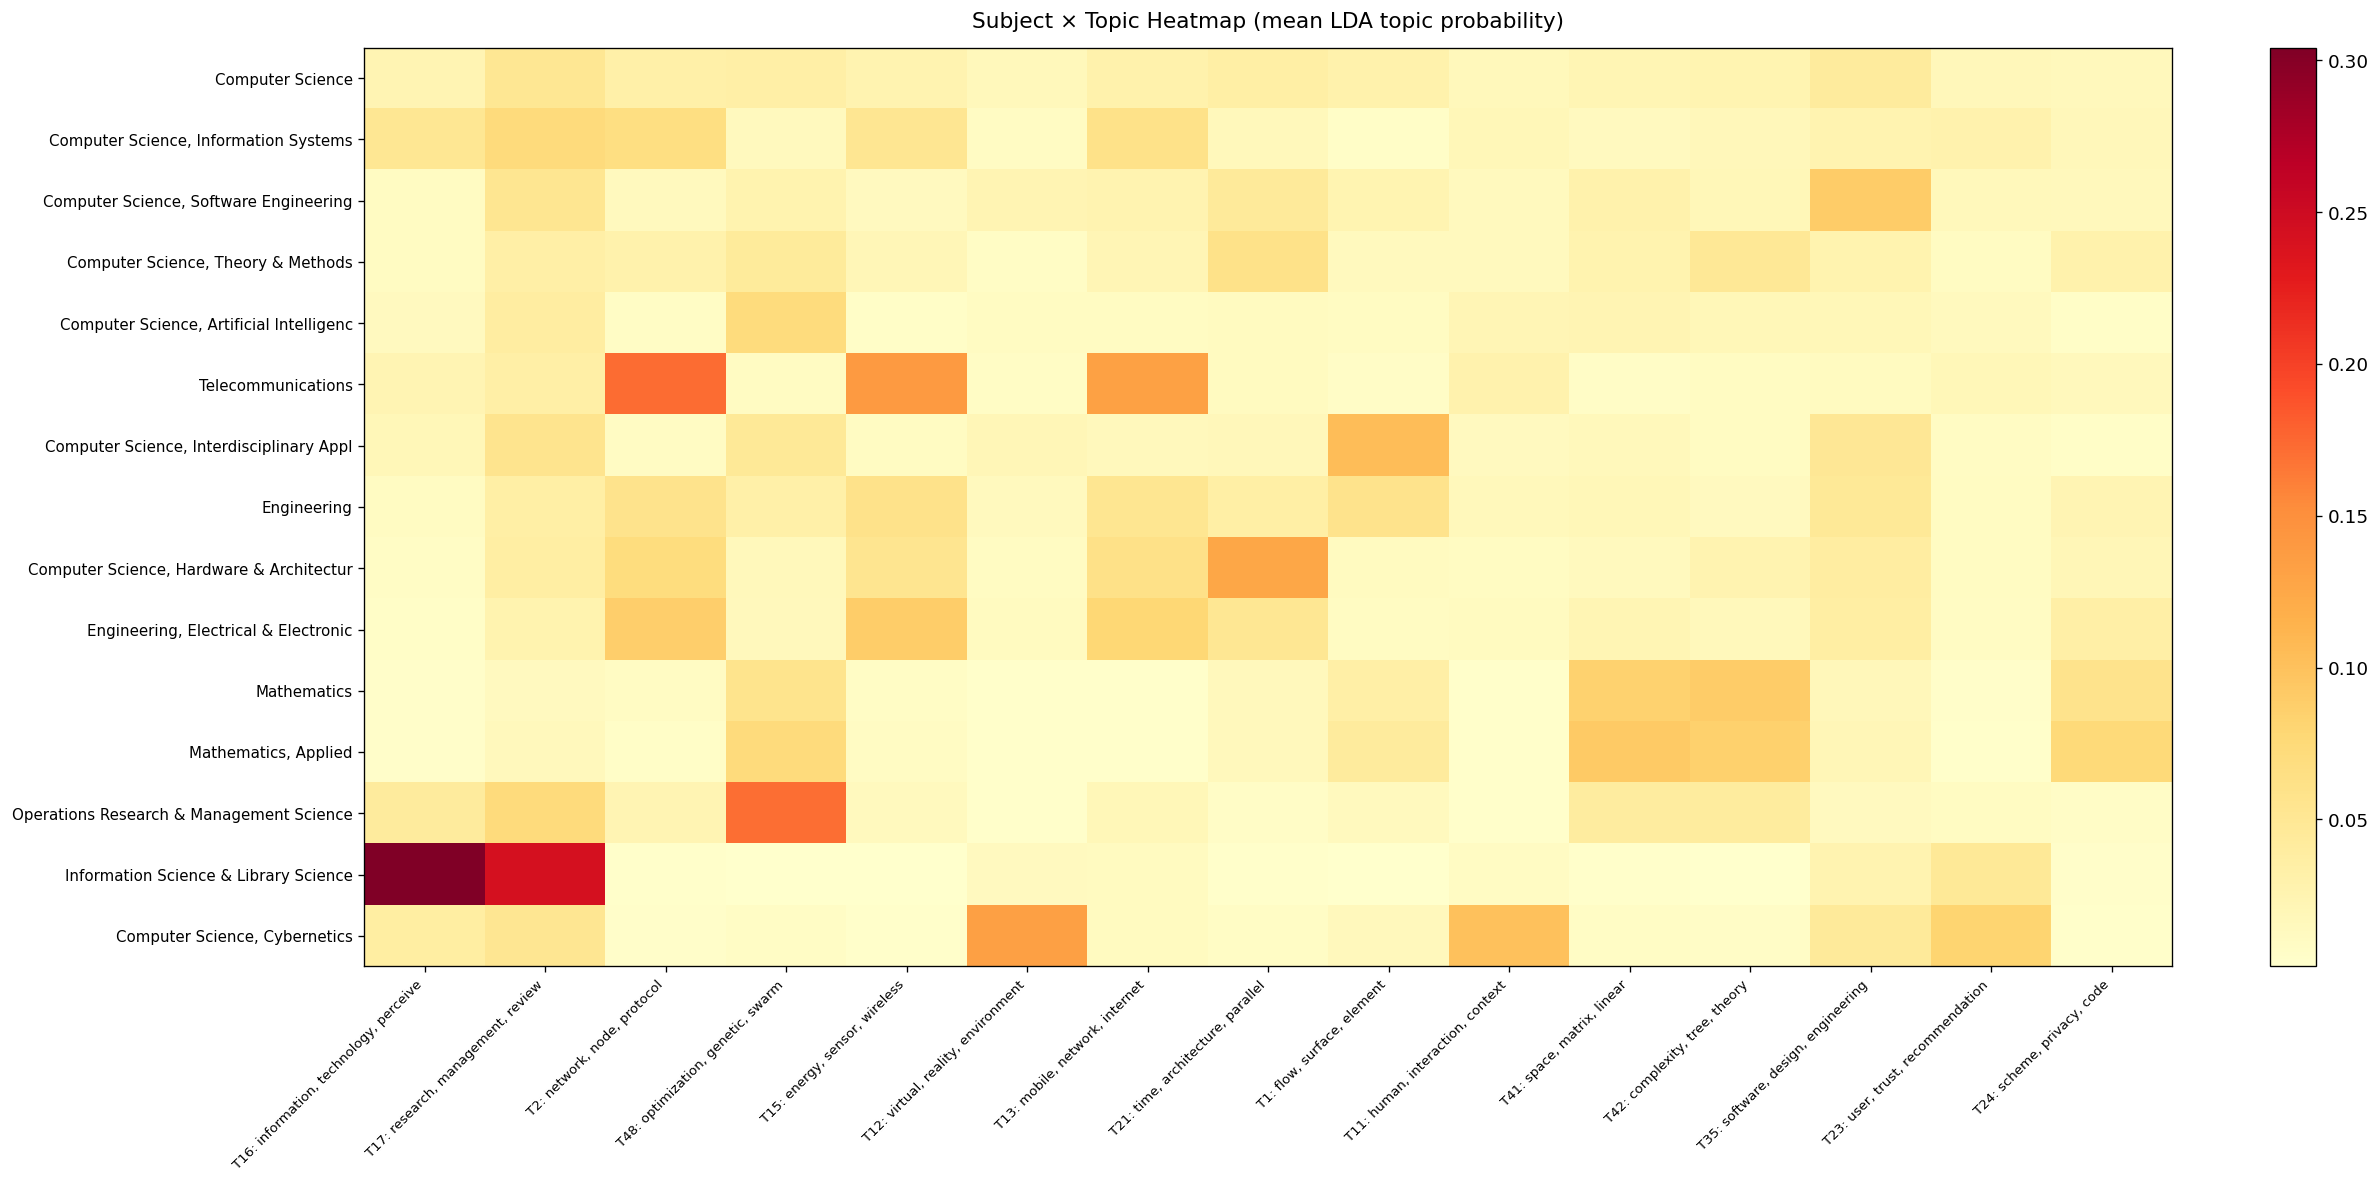

In [10]:
from src.clustering import plot_subject_topic_heatmap

plot_subject_topic_heatmap(
    df, lda_model, dictionary,
    text_col="processed_text",
    subjects_col="subjects",
    top_n_subjects=15,
    top_n_topics=15,
    figsize=(20, 10),
    save_path=pathlib.Path("../data/outputs/fig_subject_topic_heatmap.png"),
)


## 5. Per-Subject Word Clouds

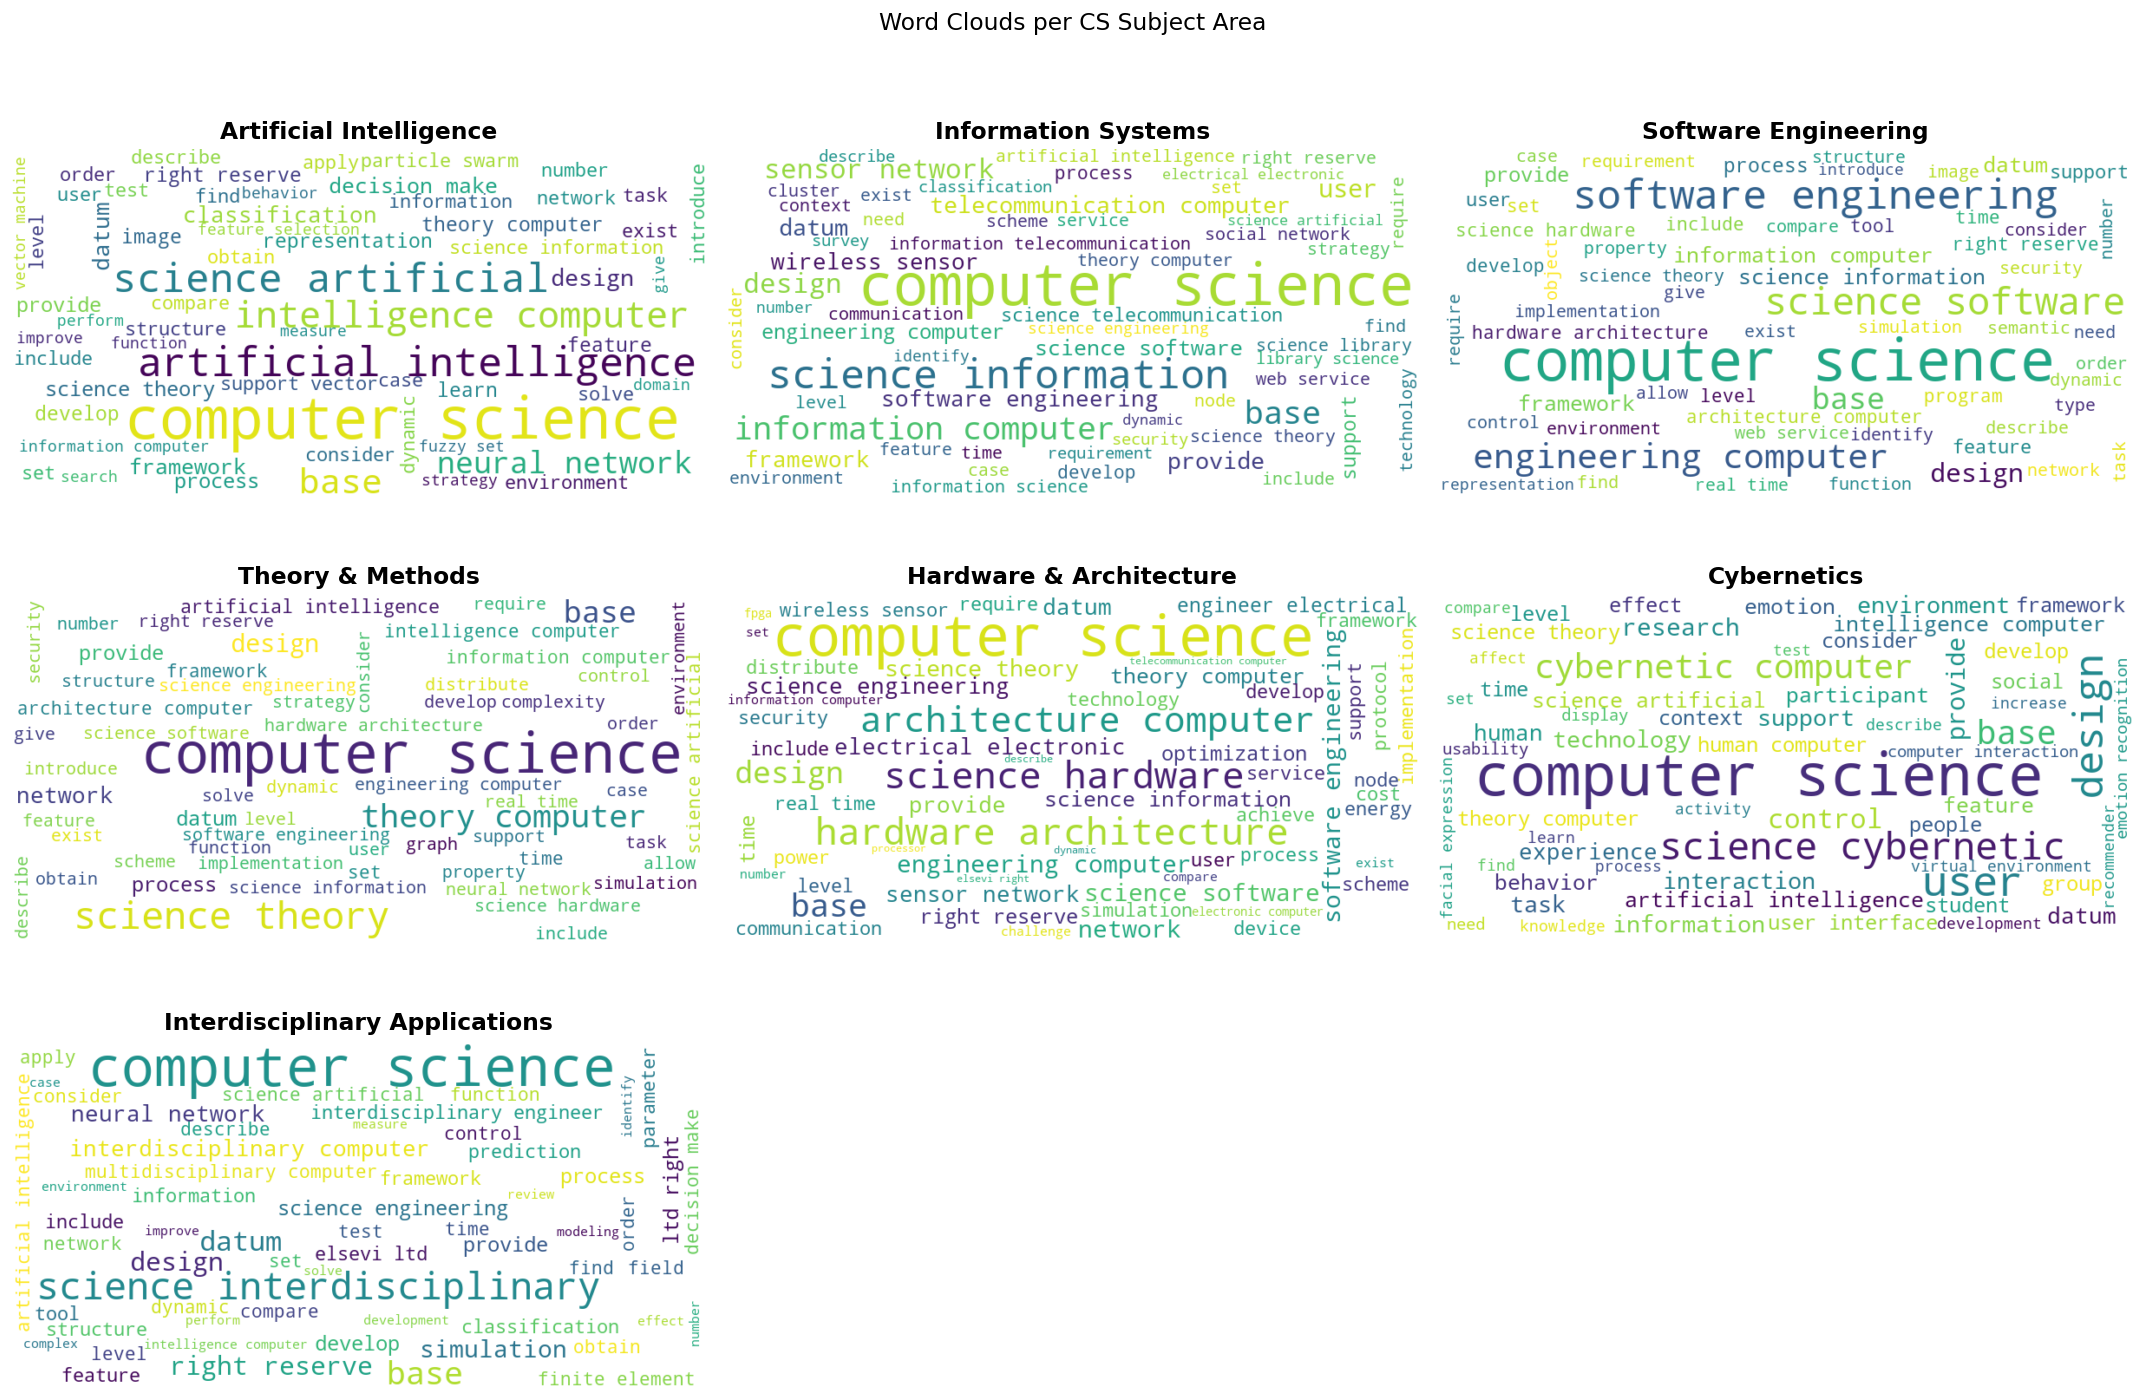

In [11]:
from src.clustering import plot_wordcloud

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax_idx, (subj, df_c) in enumerate(clustered_subjects.items()):
    text = " ".join(df_c["processed_text"].fillna("").tolist())
    short = subj.replace("Computer Science, ", "")
    plot_wordcloud(text, title=short, max_words=60, ax=axes[ax_idx])

for ax in axes[len(clustered_subjects):]:
    ax.set_visible(False)

plt.suptitle("Word Clouds per CS Subject Area", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../data/outputs/fig_subject_wordclouds.png", bbox_inches="tight", dpi=150)
plt.show()


## 6. Export Subject Topics JSON

In [12]:
from src.clustering import export_subject_topics_json
import json

out = export_subject_topics_json(clustered_subjects,
                                  title_col="title",
                                  out_path=pathlib.Path("../data/outputs/subject_topics.json"))
with open(out) as f:
    topics = json.load(f)

# Pretty-print first subject
first_subj = list(topics.keys())[0]
print(f"Subject: {first_subj}")
for cl in topics[first_subj][:3]:
    print(f"  Cluster {cl['cluster_id']}: {cl['label']} ({cl['n_articles']} articles)")
    for t in cl['example_titles'][:2]:
        print(f"    - {t[:80]}")


[JSON] Subject topics saved to ..\data\outputs\subject_topics.json
Subject: Computer Science, Artificial Intelligence
  Cluster 21: recognition, object, computer, human, video (137 articles)
    - A Survey of Appearance Models in Visual Object Tracking
    - Vision based hand gesture recognition for human computer interaction: a survey
  Cluster 80: semantic, computer, science, text, word (116 articles)
    - Conditional Random Fields for Korean Morpheme Segmentation and POS Tagging
    - Keyword Extraction from Arabic Documents using Term Equivalence Classes
  Cluster 41: agent, multi, negotiation, multi agent, science (110 articles)
    - Specifying Protocols for Multi-Agent Systems Interaction
    - Agent Clustering Based on Semantic Negotiation


## Summary

- **Global LDA (K=50):** Discovers coherent topics like *neural networks*, *network security*, *query optimization*, *computer vision*, *wireless protocols*, etc. Interactive visualisation exported to `data/outputs/lda_vis.html`.
- **Per-subject UMAP + HDBSCAN:** Each CS subject decomposes into meaningful sub-clusters. For example, "Computer Science, Artificial Intelligence" splits into clusters for NLP, computer vision, reinforcement learning, knowledge representation, etc.
- **Subject × Topic Heatmap:** Shows broad alignment between LDA topics and WoS subject categories, while still requiring human interpretation because some topics and clusters are mixed.
- **Full topic map:** `data/outputs/subject_topics.json`
